In [18]:
import pandas as pd

df = pd.read_csv("../data/raw/elastic_tensor.csv", skiprows=1)
df.head()

,idx,G_Reuss,G_VRH,G_Voigt,K_Reuss,K_VRH,K_Voigt,compliance_tensor,elastic_anisotropy,elastic_tensor,elastic_tensor_original,formula,kpoint_density,material_id,nsites,poisson_ratio,poscar,space_group,structure,volume
0,0,96.844535,97.141604,97.438674,194.267623,194.268884,194.270146,"[[0.004385293093993, -0.0016070693558990002, -...",0.030688,"[[311.33514638650246, 144.45092552856926, 126....","[[311.33514638650246, 144.45092552856926, 126....",Nb4CoSi,7000,mp-10003,12,0.285701,Nb8 Co2 Si2\n1.0\n6.221780 0.000000 0.000000\n...,124,#\#CIF1.1\n###################################...,194.419802
1,1,93.939650,96.252006,98.564362,173.647763,175.449907,177.252050,"[[0.0037715428949660003, -0.000844229828709, -...",0.266910,"[[306.93357350984974, 88.02634955100905, 105.6...","[[306.93357350984974, 88.02634955100905, 105.6...",Al(CoSi)2,7000,mp-10010,5,0.268105,Al1 Co2 Si2\n1.0\n3.932782 0.000000 0.000000\n...,164,#\#CIF1.1\n###################################...,61.987320
2,2,120.962289,130.112955,139.263621,295.077545,295.077545,295.077545,"[[0.0019959391925840004, -0.000433146670736000...",0.756489,"[[569.5291276937579, 157.8517489654999, 157.85...","[[569.5291276937579, 157.8517489654999, 157.85...",SiOs,7000,mp-10015,2,0.307780,Si1 Os1\n1.0\n2.960692 0.000000 0.000000\n0.00...,221,#\#CIF1.1\n###################################...,25.952539
3,3,12.205989,15.101901,17.997812,49.025963,49.130670,49.235377,"[[0.021647143908635, -0.005207263618160001, -0...",2.376805,"[[69.28798774976904, 34.7875015216915, 37.3877...","[[70.13259066665267, 40.60474945058445, 37.387...",Ga,7000,mp-10021,4,0.360593,Ga4\n1.0\n2.803229 0.000000 0.000000\n0.000000...,63,#\#CIF1.1\n###################################...,76.721433
4,4,100.110773,101.947798,103.784823,255.055257,256.768081,258.480904,"[[0.00410214297725, -0.001272204332729, -0.001...",0.196930,"[[349.3767766177825, 186.67131003104407, 176.4...","[[407.4791016459293, 176.4759188081947, 213.83...",SiRu2,7000,mp-10025,12,0.324682,Si4 Ru8\n1.0\n4.037706 0.000000 0.000000\n0.00...,62,#\#CIF1.1\n###################################...,160.300999


In [19]:
df.columns

Index(['idx', 'G_Reuss', 'G_VRH', 'G_Voigt', 'K_Reuss', 'K_VRH', 'K_Voigt',
       'compliance_tensor', 'elastic_anisotropy', 'elastic_tensor',
       'elastic_tensor_original', 'formula', 'kpoint_density', 'material_id',
       'nsites', 'poisson_ratio', 'poscar', 'space_group', 'structure',
       'volume'],
      dtype='str')

In [20]:
target = "K_VRH"

features = [
    "nsites",
    "volume",
    "space_group",
    "kpoint_density",
    "elastic_anisotropy"
]

target, features

('K_VRH',
 ['nsites', 'volume', 'space_group', 'kpoint_density', 'elastic_anisotropy'])

In [21]:
df.shape

(1181, 20)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idx                      1181 non-null   int64  
 1   G_Reuss                  1181 non-null   float64
 2   G_VRH                    1181 non-null   float64
 3   G_Voigt                  1181 non-null   float64
 4   K_Reuss                  1181 non-null   float64
 5   K_VRH                    1181 non-null   float64
 6   K_Voigt                  1181 non-null   float64
 7   compliance_tensor        1181 non-null   str    
 8   elastic_anisotropy       1181 non-null   float64
 9   elastic_tensor           1181 non-null   str    
 10  elastic_tensor_original  1181 non-null   str    
 11  formula                  1181 non-null   str    
 12  kpoint_density           1181 non-null   int64  
 13  material_id              1181 non-null   str    
 14  nsites                   1181 non-n

In [23]:
df.isnull().sum()

idx                        0
G_Reuss                    0
G_VRH                      0
G_Voigt                    0
K_Reuss                    0
K_VRH                      0
K_Voigt                    0
compliance_tensor          0
elastic_anisotropy         0
elastic_tensor             0
elastic_tensor_original    0
formula                    0
kpoint_density             0
material_id                0
nsites                     0
poisson_ratio              0
poscar                     0
space_group                0
structure                  0
volume                     0
dtype: int64

In [24]:
df_clean = df[[
    "nsites",
    "volume",
    "space_group",
    "kpoint_density",
    "elastic_anisotropy",
    "K_VRH"
]]

df_clean.head()

,nsites,volume,space_group,kpoint_density,elastic_anisotropy,K_VRH
0,12,194.419802,124,7000,0.030688,194.268884
1,5,61.987320,164,7000,0.266910,175.449907
2,2,25.952539,221,7000,0.756489,295.077545
3,4,76.721433,63,7000,2.376805,49.130670
4,12,160.300999,62,7000,0.196930,256.768081


In [25]:
df_clean = df[[
    "nsites",
    "volume",
    "space_group",
    "elastic_anisotropy",
    "K_VRH"
]]

df_clean.head()

,nsites,volume,space_group,elastic_anisotropy,K_VRH
0,12,194.419802,124,0.030688,194.268884
1,5,61.987320,164,0.266910,175.449907
2,2,25.952539,221,0.756489,295.077545
3,4,76.721433,63,2.376805,49.130670
4,12,160.300999,62,0.196930,256.768081


In [26]:
df_clean["K_VRH"].describe()

count    1181.000000
mean      136.259661
std        72.886978
min         6.476135
25%        76.435350
50%       130.382766
75%       189.574194
max       435.661487
Name: K_VRH, dtype: float64

In [27]:
df_clean.describe()

,nsites,volume,space_group,elastic_anisotropy,K_VRH
count,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000
mean,12.425910,207.177098,163.403895,2.145013,136.259661
std,11.817997,192.355747,65.040733,19.140097,72.886978
min,2.000000,15.850527,4.000000,0.000005,6.476135
25%,5.000000,83.944059,124.000000,0.145030,76.435350
50%,10.000000,168.920404,193.000000,0.355287,130.382766
75%,16.000000,261.420345,221.000000,0.923117,189.574194
max,152.000000,2398.906164,229.000000,397.297866,435.661487


In [28]:
for col in df_clean.columns:
    print(col, ":", df_clean[col].nunique())

nsites : 41
volume : 1181
space_group : 87
elastic_anisotropy : 1181
K_VRH : 1181


In [29]:
df_clean.to_csv("../data/processed/clean_materials_data.csv", index=False)

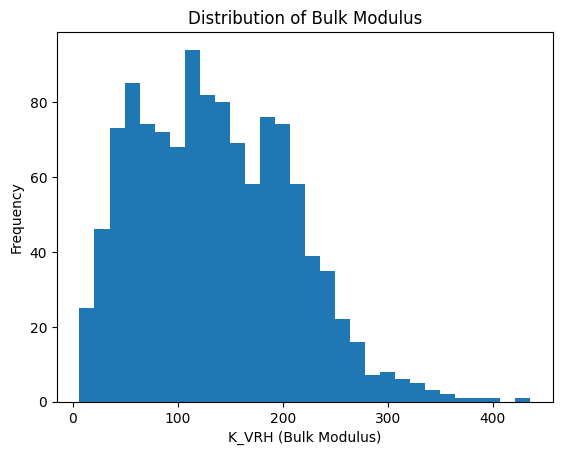

In [30]:
import matplotlib.pyplot as plt

plt.hist(df_clean["K_VRH"], bins=30)
plt.xlabel("K_VRH (Bulk Modulus)")
plt.ylabel("Frequency")
plt.title("Distribution of Bulk Modulus")
plt.show()

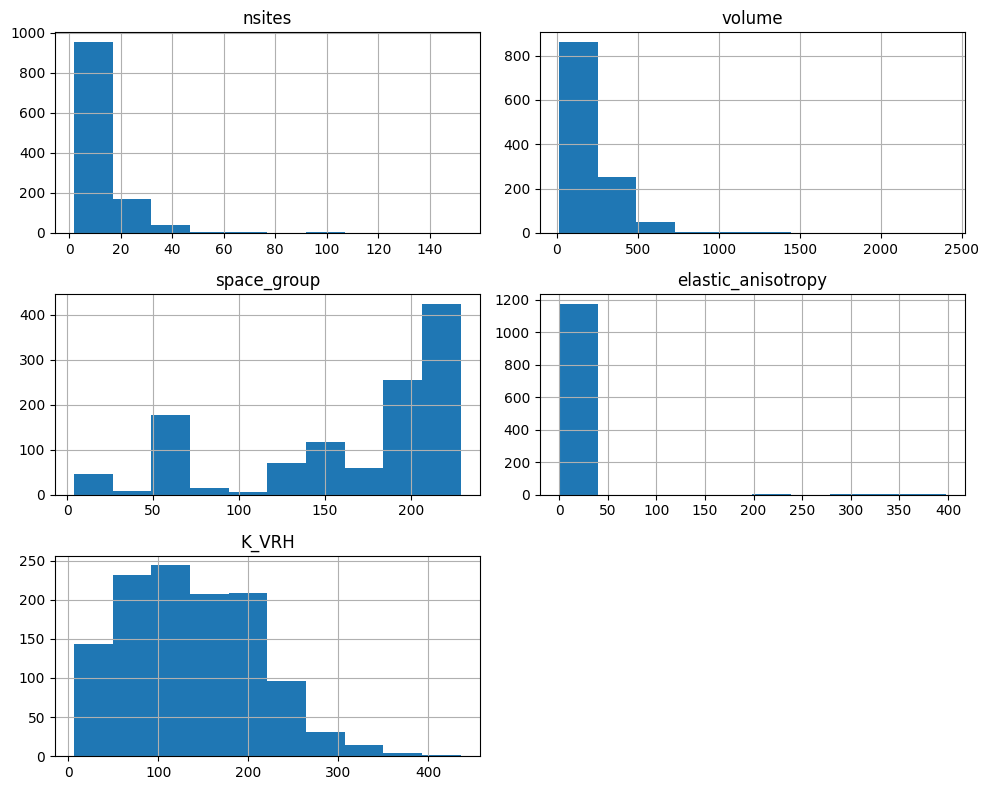

In [31]:
df_clean.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

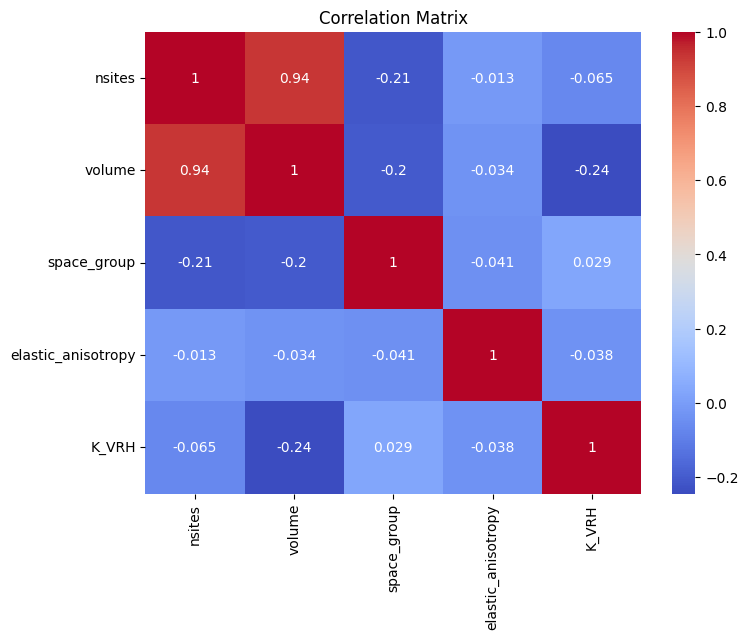

In [33]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

EDA Summary:

- Target (K_VRH) is right-skewed with some high-value outliers.
- Volume shows the strongest correlation with K_VRH (~ -0.24).
- Most features have weak linear relationships with the target.
- Nsites and volume are highly correlated (~0.94), indicating redundancy.
- Elastic anisotropy has extreme skewness and potential outliers.
- Space group behaves like a categorical variable, not numerical.